Name: Thomas Sears
Date: 8/29/26
Lab 1 - Projectile Motion Solver

In [10]:
import numpy as np
import matplotlib.pyplot as plt

Part A - One-Dimensional Free Fall

Description: Using a function (simulate_freefall), calculates the time for a projectile to hit the ground from height h with no air resistence using Euler's method by summing over time steps, dt. Returns lists containing instantaneous time, y-position, and the y-component of velocity.

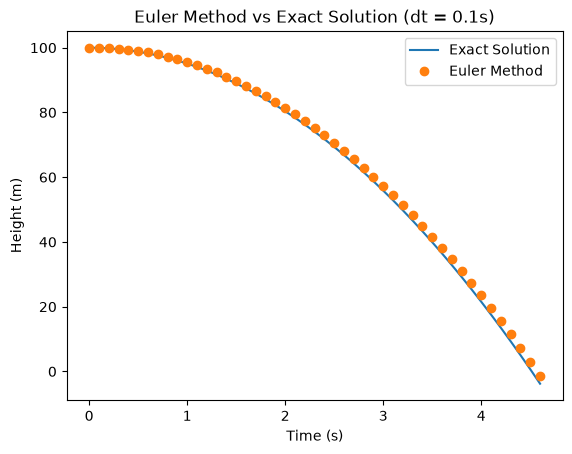

My Simulation -

Final Time to Hit Ground (seconds) :  4.6
Final Velocity (Negative Y-Direction in m/s) :  -45.13

Exact Solution -

Final Time to Hit Ground (seconds) :  4.52
Final Velocity (Negative Y-Direction in m/s) :  -44.29
Percent Error:  1.77


In [11]:
# Parameters
h = 100
dt = 0.1
g = 9.81

def simulate_freefall(h, dt, g):

    #Initialize Variables
    y = h
    vy = 0.0
    t = 0.0

    # List Quantities
    t_arr, y_arr, vy_arr = [t], [y], [vy]

    # Euler Method
    while y >= 0:

        # Y-Axis Acceleration (Negative Direction)
        ay = -g

        # Update Quantities
        y = y + vy * dt
        vy = vy + ay * dt
        t = t + dt

        t_arr.append(t)
        y_arr.append(y)
        vy_arr.append(vy)

    return t_arr, y_arr, vy_arr

# Plot Exact Solution and Euler Method Solution
t_arr, y_arr, vy_arr = simulate_freefall(h, dt, g)

# Calculates Exact Solutions for Position
y_exact = []
for t in t_arr:
    y_exact.append(100 - 0.5 * 9.81 * t**2)

plt.plot(t_arr, y_exact, label="Exact Solution")
plt.plot(t_arr, y_arr, 'o', label="Euler Method")

plt.title("Euler Method vs Exact Solution (dt = 0.1s)")
plt.xlabel("Time (s)")
plt.ylabel("Height (m)")
plt.legend()
plt.show()

# Rounded Numerical Values
tf_numerical = round(t_arr[-1], 2)
vy_numerical = round(vy_arr[-1], 2)

print("My Simulation -\n")
print("Final Time to Hit Ground (seconds) : ", tf_numerical)
print("Final Velocity (Negative Y-Direction in m/s) : ", vy_numerical)

# Calculates Exact Solutions for Final Time and Velocity
tf_exact = np.sqrt(200/9.81)
vf_exact = -9.81 * tf_exact

# Rounded Values
tf_exact = round(tf_exact, 2)
vf_exact= round(vf_exact, 2)

print("\nExact Solution -\n")
print("Final Time to Hit Ground (seconds) : ", tf_exact)
print("Final Velocity (Negative Y-Direction in m/s) : ", vf_exact)

print("Percent Error: ", round(np.abs(((tf_exact - tf_numerical)/tf_exact))*100.0, 2))


Questions:

a. My calculated numerical landing time (dt = 0.1) is 4.6 seconds while the exact solution gives 4.52 seconds. This is a percent error of approximately 1.77%.

b. Using dt = 1.0, landing time is 6.0 seconds (32.74% error) compared to 1.77% error for dt = 0.1. For dt = 0.01, landing time is 4.53 seconds giving a percent error of 0.22%. We see that error increases dramatically going from dt = 0.1 to dt = 1.0 but only decreases by 1.55% going from dt = 0.1 to dt = 0.01.

Part B - Two-Dimensional Projectile

Description: Simulates a projectile using Euler's method starting from position (x, y) = (0, 0) with some initial velocity v0, angle theta, and calculates its x, y positions, x and y velocities, and time taken to hit the ground assuming no air resistence.

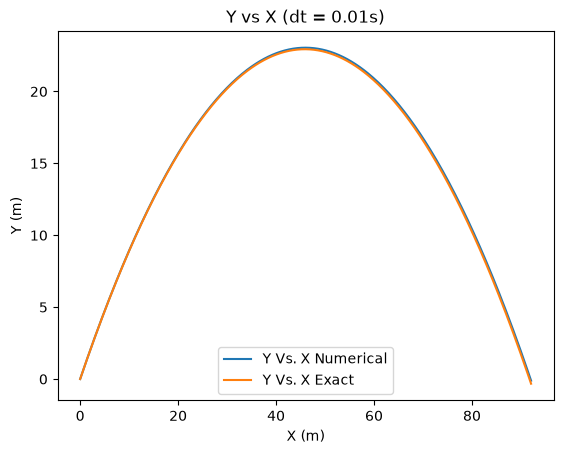

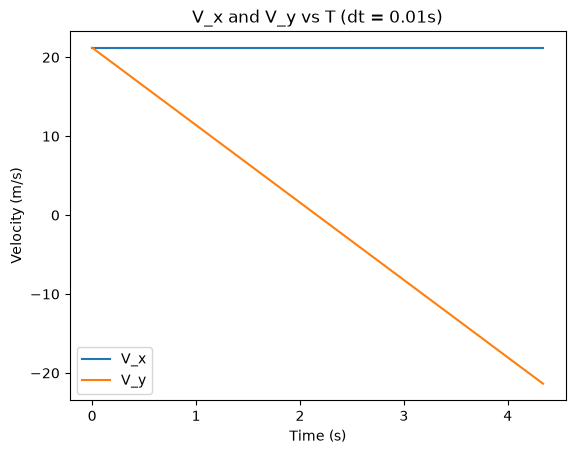

My Simulation - 

Numerical Range (m) :  92.07
Numerical Max Height (m) :  23.04
Numerical Flight Time (s) :  4.34

Exact Solution - 

Exact Range (m) :  91.74
Exact Max Height (m) :  22.94
Exact Flight Time (s) :  4.32

Percent Error - 

Range :  0.36
Max Height :  0.44
Flight Time :  0.46


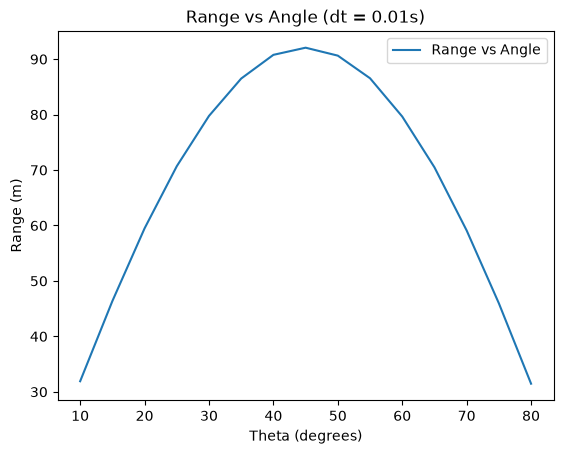

My numerical simulation predicts that the optimal angle for range is 45 degrees which does match the prediction by the theory


In [12]:
# Parameters
v0 = 30
theta_deg = 45
dt = 0.01
g = 9.81

def simulate_projectile_2d(v0,theta_deg, dt, g):

    # Initialize Variables
    theta_rad = np.radians(theta_deg)
    y = 0.0
    x = 0.0
    vy = v0 * np.sin(theta_rad)
    vx = v0 * np.cos(theta_rad)
    v = np.sqrt(vx**2 + vy**2)
    t = 0.0

    # List Quantities
    t_arr, y_arr, x_arr, vy_arr, vx_arr, v_arr = [t], [y], [x], [vy], [vx], [v]

    # Euler Method
    while y >= 0:

        # Y-Axis Acceleration (Negative Direction)
        ay = -g

        # X-Axis Acceleration
        ax = 0

        # Update Quantities
        y = y + vy * dt
        x = x + vx * dt
        vy = vy + ay * dt
        vx = vx + ax * dt
        v = np.sqrt(vx**2 + vy**2)
        t = t + dt

        t_arr.append(t)
        y_arr.append(y)
        x_arr.append(x)
        vy_arr.append(vy)
        vx_arr.append(vx)
        v_arr.append(v)

    return t_arr, y_arr, x_arr, vy_arr, vx_arr, v_arr

t_arr, y_arr, x_arr, vy_arr, vx_arr, v_arr = simulate_projectile_2d(v0, theta_deg, dt, g)

# Exact Solutions
y_exact = []
for t in t_arr:
    y_exact.append((v0 * np.sin(np.radians(theta_deg)) * t) - (0.5 * 9.81 * t**2))

x_exact = []
for t in t_arr:
    x_exact.append(v0 * np.cos(np.radians(theta_deg)) * t)

# Plot Number 1 - y vs. x
plt.plot(x_arr, y_arr, label="Y Vs. X Numerical")
plt.plot(x_exact, y_exact, label="Y Vs. X Exact")
plt.title("Y vs X (dt = 0.01s)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.legend()
plt.show()

# Plot Number 2 - vx and vy vs t
plt.plot(t_arr, vx_arr, label="V_x")
plt.plot(t_arr, vy_arr, label="V_y")

plt.title("V_x and V_y vs T (dt = 0.01s)")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.show()

# Compare Numerical and Exact Values (Rounded to 2 Decimal Places)
range_exact = round(v0**2 * np.sin(2*(np.radians(theta_deg))) / g, 2)
max_height_exact = round((v0**2) * ((np.sin(np.radians(theta_deg)))**2) / (2 * g), 2)
flight_time_exact = round(2 * v0 * np.sin(np.radians(theta_deg)) / g, 2)

range_numerical = round(max(x_arr), 2)
max_height_numerical = round(max(y_arr), 2)
flight_time_numerical = round(max(t_arr), 2)

range_error = round(np.abs(((range_exact - range_numerical)/range_exact))*100.0, 2)
max_height_error = round(np.abs(((max_height_exact - max_height_numerical)/max_height_exact))*100.0, 2)
flight_time_error = round(np.abs(((flight_time_exact - flight_time_numerical)/flight_time_exact))*100.0, 2)

print("My Simulation - \n")
print("Numerical Range (m) : ", range_numerical)
print("Numerical Max Height (m) : ", max_height_numerical)
print("Numerical Flight Time (s) : ", flight_time_numerical)

print("\nExact Solution - \n")
print("Exact Range (m) : ", range_exact)
print("Exact Max Height (m) : ", max_height_exact)
print("Exact Flight Time (s) : ", flight_time_exact)

print("\nPercent Error - \n")
print("Range : ", range_error)
print("Max Height : ", max_height_error)
print("Flight Time : ", flight_time_error)

# Angle Sweep
angle = 10
range_arr = []
angle_arr = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]

while angle <= 80:
    x_arr = simulate_projectile_2d(v0, angle, dt, g)[2]
    range_arr.append(max(x_arr))
    angle += 5


plt.plot(angle_arr, range_arr, label="Range vs Angle")
plt.title("Range vs Angle (dt = 0.01s)")
plt.xlabel("Theta (degrees)")
plt.ylabel("Range (m)")
plt.legend()
plt.show()

print("My numerical simulation predicts that the optimal angle for range is 45 degrees which does match the prediction by the theory")

V_x and V_y vs T Curve Explination:

The V_x curve is completely horizontal with a slope of 0 because there are no forces acting opposite to the direction of motion along the x-axis. The V_y curve has a linear decreaing shape because it has a constant negative rate of change of -9.81 (y-axis acceleration).

Questions:

a. V_x is constant because there are no opposing forces acting in the x-direction that would slow down the projectile. V_y is linear because the only force acting upon the projectile in the y-direction is gravity which is held constant, meaning V_y has a constant and negative rate of change.

b. My simulation gave an optimal angle of 45 degrees for range which is in accordance with the theory. This is expected considering my simulation uses dt = 0.01 which gives a nice approximation to the theory with a low percent error for range of less than 1%.

c. When increasing dt to 0.5 s, the range vs angle graph becomes wildy inaccurate. What goes wrong is that at high dt, the O(t^2) term in the Euler method Taylor expansion starts to become significant leading to massive error propegation. (Graph Below)



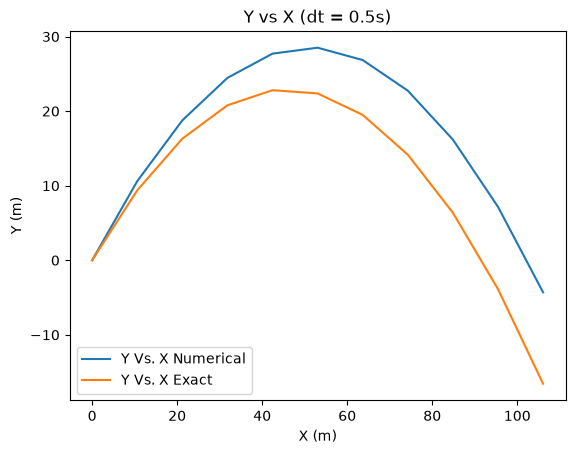

In [13]:
# Graph for Part C of Questions


# Parameters
v0 = 30
theta_deg = 45
dt = 0.5
g = 9.81

t_arr, y_arr, x_arr, vy_arr, vx_arr, v_arr = simulate_projectile_2d(v0, theta_deg, dt, g)

# Exact Solutions
y_exact = []
for t in t_arr:
    y_exact.append((v0 * np.sin(np.radians(theta_deg)) * t) - (0.5 * 9.81 * t**2))

x_exact = []
for t in t_arr:
    x_exact.append(v0 * np.cos(np.radians(theta_deg)) * t)

# Plot (dt = 0.5)
plt.plot(x_arr, y_arr, label="Y Vs. X Numerical")
plt.plot(x_exact, y_exact, label="Y Vs. X Exact")
plt.title("Y vs X (dt = 0.5s)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.legend()
plt.show()

Part C - Projectile with Air Resistance

Description: Simulates a projectile using Euler's method lauched with some initial velocity and angle with drag forces taken into account. The function returns values for x and y positions, total speed v, components of v, v_x and v_y, aswell as time.

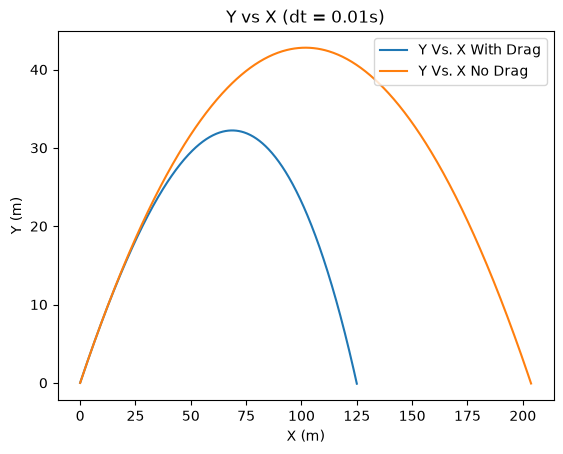

With Drag - 

Range (m) :  125.0
Max Height (m) :  32.22

Without Drag - 

Range (m) :  203.73
Max Height (m) :  42.79

Percent Difference - 

Range :  38.64
Max Height :  24.7


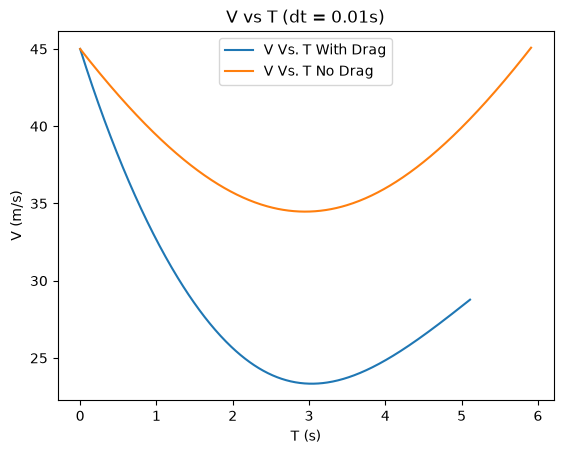

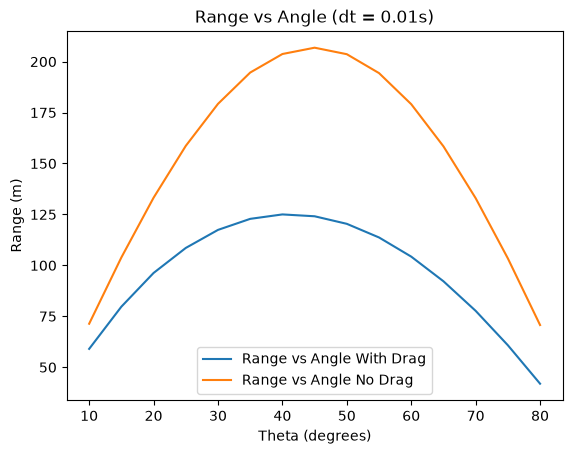

With drag, the optimal angle is now around 40 degrees instead of 45 degrees for no drag


In [14]:
# Parameters
v0 = 45
theta_deg = 40
b_over_m = 0.0046
dt = 0.01

def simulate_projectile_drag(v0, theta_deg, dt, g, b_over_m):
    # Initialize Variables
    theta_rad = np.radians(theta_deg)
    y = 0.0
    x = 0.0
    vy = v0 * np.sin(theta_rad)
    vx = v0 * np.cos(theta_rad)
    v = np.sqrt(vx**2 + vy**2)
    t = 0.0

    # List Quantities
    t_arr, y_arr, x_arr, vy_arr, vx_arr, v_arr = [t], [y], [x], [vy], [vx], [v]

    # Euler Method
    while y >= 0:

        # Y-Axis Acceleration (Negative Direction)
        ay = -g -(b_over_m) * v * vy

        # X-Axis Acceleration
        ax = -(b_over_m) * v * vx

        # Update Quantities
        y = y + vy * dt
        x = x + vx * dt
        vy = vy + ay * dt
        vx = vx + ax * dt
        v = np.sqrt(vx**2 + vy**2)
        t = t + dt

        t_arr.append(t)
        y_arr.append(y)
        x_arr.append(x)
        vy_arr.append(vy)
        vx_arr.append(vx)
        v_arr.append(v)

    return t_arr, y_arr, x_arr, vy_arr, vx_arr, v_arr

t_arr, y_arr, x_arr, vy_arr, vx_arr, v_arr = simulate_projectile_drag(v0, theta_deg, dt, g, b_over_m)
t_nodrag, y_nodrag, x_nodrag, vy_nodrag, vx_nodrag, v_nodrag = simulate_projectile_2d(v0, theta_deg, dt, g)

# Plot Drag vs No Drag
plt.plot(x_arr, y_arr, label="Y Vs. X With Drag")
plt.plot(x_nodrag, y_nodrag, label="Y Vs. X No Drag")
plt.title("Y vs X (dt = 0.01s)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.legend()
plt.show()

# Get range and max height w/ and without drag and percent difference (rounded to 2 decimal places)
range_drag = round(max(x_arr), 2)
max_height_drag = round(max(y_arr), 2)

range_nodrag = round(max(x_nodrag), 2)
max_height_nodrag = round(max(y_nodrag), 2)

range_diff = round(((range_nodrag - range_drag) / range_nodrag) * 100.0, 2)
max_height_diff = round(((max_height_nodrag - max_height_drag) / max_height_nodrag) * 100.0, 2)

print("With Drag - \n")
print("Range (m) : ", range_drag )
print("Max Height (m) : ", max_height_drag)

print("\nWithout Drag - \n")
print("Range (m) : ", range_nodrag)
print("Max Height (m) : ", max_height_nodrag)

print("\nPercent Difference - \n")
print("Range : ", range_diff)
print("Max Height : ", max_height_diff)

# Plot Speed vs Time for no drag and drag
plt.plot(t_arr, v_arr, label="V Vs. T With Drag")
plt.plot(t_nodrag, v_nodrag, label="V Vs. T No Drag")
plt.title("V vs T (dt = 0.01s)")
plt.xlabel("T (s)")
plt.ylabel("V (m/s)")
plt.legend()
plt.show()

# Angle Sweep
angle = 10
range_arr_drag = []
range_arr_nodrag = []
angle_arr = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]

while angle <= 80:
    x_arr_drag = simulate_projectile_drag(v0, angle, dt, g, b_over_m)[2]
    range_arr_drag.append(max(x_arr_drag))
    angle += 5

# Reset angle
angle = 10

while angle <= 80:
    x_arr_nodrag = simulate_projectile_2d(v0, angle, dt, g)[2]
    range_arr_nodrag.append(max(x_arr_nodrag))
    angle += 5

plt.plot(angle_arr, range_arr_drag, label="Range vs Angle With Drag")
plt.plot(angle_arr, range_arr_nodrag, label="Range vs Angle No Drag")
plt.title("Range vs Angle (dt = 0.01s)")
plt.xlabel("Theta (degrees)")
plt.ylabel("Range (m)")
plt.legend()
plt.show()

print("With drag, the optimal angle is now around 40 degrees instead of 45 degrees for no drag")

Questions:

a. The drag force is at its strongest when the projectile is moving at max speed because the drag force scales directly with v. This means that the drag force very quickly acts on the projectile early on into its trajectory which causes the immense difference between range with and without drag.

b. Launching the projectile at an angle of 45 or more maximizes the velocity in the y-direction which in turn causes the projectile to be in the air longer which gives the drag force more time to slow down the projectile. So, the optimal trajectory is one that balances increasing the initial speed in the x-direction with enough time for the projectile to travel where theta < 45 degrees.

c. Overall, I would say the Euler Method works relatively well for this type of problem, however, it depends massively on dt. Large dt causes everything to fail rather quickly as dt increases from 0.01 seconds. To check if the method is reasonable, I would lower dt as much as possible to see if the results are consistent from low dt of around 0.01 to something maybe of order 0.0001 or so.